In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from pathlib import Path

PROCESSED = Path("../data/processed")
RAW = Path("../data/raw")

nav = pd.read_csv(RAW / "02_nav_history.csv", parse_dates=["date"])
nav = nav.sort_values(["amfi_code", "date"]).reset_index(drop=True)

print(nav.shape)
print(nav.head())

(46000, 3)
   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639


In [2]:
# ── TASK 1: Daily Returns ─────────────────────────────────────────────
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()
nav["annualised_return"] = (1 + nav["daily_return"]).rolling(252).apply(np.prod) - 1
nav.to_csv(PROCESSED / "returns_computed.csv", index=False)
print("Daily returns done:", nav["daily_return"].describe())

# ── TASK 2: CAGR ──────────────────────────────────────────────────────
def cagr(group, years):
    group = group.sort_values("date")
    cutoff = group["date"].max() - pd.DateOffset(years=years)
    subset = group[group["date"] >= cutoff]
    if len(subset) < 2:
        return np.nan
    nav_end = subset["nav"].iloc[-1]
    nav_start = subset["nav"].iloc[0]
    n = len(subset) / 252
    return (nav_end / nav_start) ** (1/n) - 1

cagr_rows = []
for code, grp in nav.groupby("amfi_code"):
    cagr_rows.append({
        "amfi_code": code,
        "cagr_1yr": cagr(grp, 1),
        "cagr_3yr": cagr(grp, 3),
        "cagr_5yr": cagr(grp, 5)
    })
cagr_df = pd.DataFrame(cagr_rows)
cagr_df.to_csv(PROCESSED / "cagr_report.csv", index=False)
print("\nCAGR Report:")
print(cagr_df.head())

# ── TASK 3: Sharpe Ratio ──────────────────────────────────────────────
Rf = 0.065 / 252  # daily risk-free rate
sharpe_rows = []
for code, grp in nav.groupby("amfi_code"):
    returns = grp["daily_return"].dropna()
    excess = returns - Rf
    sharpe = (excess.mean() / returns.std()) * np.sqrt(252) if returns.std() > 0 else np.nan
    sharpe_rows.append({"amfi_code": code, "sharpe_ratio": sharpe})
sharpe_df = pd.DataFrame(sharpe_rows).sort_values("sharpe_ratio", ascending=False)
sharpe_df.to_csv(PROCESSED / "sharpe_values.csv", index=False)
print("\nTop 5 Sharpe:")
print(sharpe_df.head())

# ── TASK 4: Sortino Ratio ─────────────────────────────────────────────
sortino_rows = []
for code, grp in nav.groupby("amfi_code"):
    returns = grp["daily_return"].dropna()
    excess = returns - Rf
    downside = returns[returns < 0].std()
    sortino = (excess.mean() / downside) * np.sqrt(252) if downside > 0 else np.nan
    sortino_rows.append({"amfi_code": code, "sortino_ratio": sortino})
sortino_df = pd.DataFrame(sortino_rows)
sortino_df.to_csv(PROCESSED / "sortino_values.csv", index=False)
print("\nSortino done")

# ── TASK 5: Alpha & Beta ──────────────────────────────────────────────
# Use average of all funds as benchmark proxy
benchmark = nav.groupby("date")["daily_return"].mean().reset_index()
benchmark.columns = ["date", "benchmark_return"]

alpha_beta_rows = []
for code, grp in nav.groupby("amfi_code"):
    merged = grp[["date","daily_return"]].merge(benchmark, on="date").dropna()
    if len(merged) < 30:
        continue
    slope, intercept, r, p, se = stats.linregress(
        merged["benchmark_return"], merged["daily_return"]
    )
    alpha_beta_rows.append({
        "amfi_code": code,
        "beta": slope,
        "alpha": intercept * 252,
        "r_squared": r**2
    })
ab_df = pd.DataFrame(alpha_beta_rows)
ab_df.to_csv(PROCESSED / "alpha_beta.csv", index=False)
print("\nAlpha Beta done")
print(ab_df.head())

# ── TASK 6: Maximum Drawdown ──────────────────────────────────────────
dd_rows = []
for code, grp in nav.groupby("amfi_code"):
    grp = grp.sort_values("date")
    running_max = grp["nav"].cummax()
    drawdown = grp["nav"] / running_max - 1
    max_dd = drawdown.min()
    worst_date = grp.loc[drawdown.idxmin(), "date"] if not drawdown.empty else np.nan
    dd_rows.append({"amfi_code": code, "max_drawdown": max_dd, "worst_date": worst_date})
dd_df = pd.DataFrame(dd_rows)
dd_df.to_csv(PROCESSED / "max_drawdown.csv", index=False)
print("\nMax Drawdown done")

# ── TASK 7: Fund Scorecard ────────────────────────────────────────────
scorecard = cagr_df[["amfi_code","cagr_3yr"]].merge(
    sharpe_df, on="amfi_code").merge(
    ab_df[["amfi_code","alpha"]], on="amfi_code").merge(
    dd_df[["amfi_code","max_drawdown"]], on="amfi_code")

scorecard["cagr_rank"] = scorecard["cagr_3yr"].rank(ascending=False)
scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(ascending=False)
scorecard["alpha_rank"] = scorecard["alpha"].rank(ascending=False)
scorecard["dd_rank"] = scorecard["max_drawdown"].rank(ascending=True)

total = len(scorecard)
scorecard["score"] = (
    0.30 * (1 - scorecard["cagr_rank"]/total) +
    0.25 * (1 - scorecard["sharpe_rank"]/total) +
    0.20 * (1 - scorecard["alpha_rank"]/total) +
    0.10 * (1 - scorecard["dd_rank"]/total)
) * 100

scorecard = scorecard.sort_values("score", ascending=False)
scorecard.to_csv(PROCESSED / "fund_scorecard.csv", index=False)
print("\nTop 10 Funds by Score:")
print(scorecard[["amfi_code","score"]].head(10))

Daily returns done: count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

CAGR Report:
   amfi_code  cagr_1yr  cagr_3yr  cagr_5yr
0     100016 -0.021403  0.012446  0.025412
1     100025  0.035611  0.037690  0.042948
2     100033  0.507565  0.310748  0.288994
3     101206  0.457300  0.277613  0.226048
4     101207 -0.231862 -0.040021  0.076433

Top 5 Sharpe:
    amfi_code  sharpe_ratio
34     148567      1.448291
30     120843      1.306744
36     148569      1.234930
19     119551      1.208267
25     120505      1.180101

Sortino done

Alpha Beta done
   amfi_code      beta     alpha  r_squared
0     100016  0.788441 -0.089699   0.020056
1     100025  0.060713  0.033199   0.001650
2     100033  0.991590  0.114423   0.018723
3     101206  0.737015  0.097443   0.017476
4     101207  2.878184 -0.350741   0.084996

Max Drawdown done


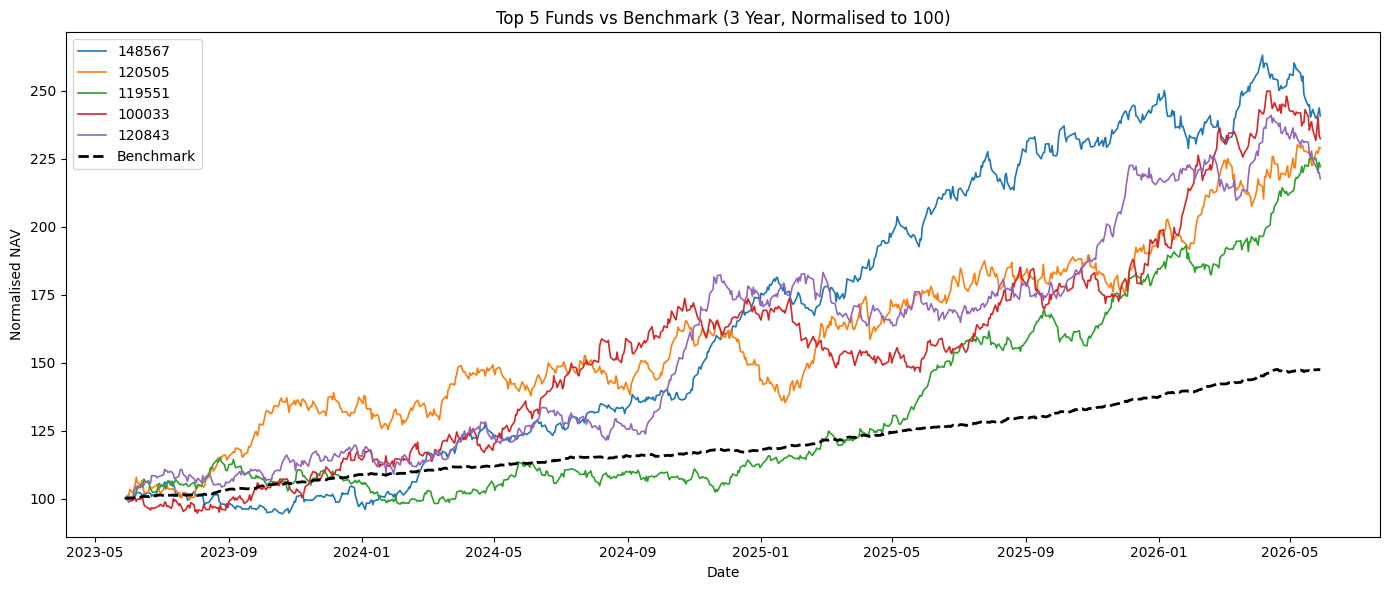

Tracking Error:
   amfi_code  tracking_error
0     148567          0.1390
1     120505          0.1870
2     119551          0.1392
3     100033          0.1814
4     120843          0.1548


In [3]:
import matplotlib.pyplot as plt

# Top 5 funds by score
top5 = scorecard.head(5)["amfi_code"].tolist()

# 3 year data
cutoff = nav["date"].max() - pd.DateOffset(years=3)
nav_3yr = nav[nav["date"] >= cutoff]

# Benchmark = equal weight average
benchmark_3yr = nav_3yr.groupby("date")["nav"].mean().reset_index()
benchmark_3yr.columns = ["date", "benchmark_nav"]

# Normalise to 100
benchmark_3yr["benchmark_norm"] = benchmark_3yr["benchmark_nav"] / benchmark_3yr["benchmark_nav"].iloc[0] * 100

plt.figure(figsize=(14,6))
for code in top5:
    subset = nav_3yr[nav_3yr["amfi_code"]==code].copy()
    subset["norm"] = subset["nav"] / subset["nav"].iloc[0] * 100
    plt.plot(subset["date"], subset["norm"], label=str(code), linewidth=1.2)

plt.plot(benchmark_3yr["date"], benchmark_3yr["benchmark_norm"], 
         label="Benchmark", color="black", linewidth=2, linestyle="--")
plt.title("Top 5 Funds vs Benchmark (3 Year, Normalised to 100)")
plt.xlabel("Date")
plt.ylabel("Normalised NAV")
plt.legend()
plt.tight_layout()
plt.savefig("../data/processed/benchmark_chart.png", dpi=150)
plt.show()

# Tracking error
tracking_rows = []
for code in top5:
    subset = nav_3yr[nav_3yr["amfi_code"]==code][["date","daily_return"]].merge(
        benchmark_3yr[["date"]].assign(
            bench_ret=nav_3yr.groupby("date")["daily_return"].mean().values[:len(benchmark_3yr)]
        ), on="date", how="inner"
    ).dropna()
    te = (subset["daily_return"] - subset["bench_ret"]).std() * np.sqrt(252)
    tracking_rows.append({"amfi_code": code, "tracking_error": round(te, 4)})

te_df = pd.DataFrame(tracking_rows)
print("Tracking Error:")
print(te_df)
plt.show()